# SWOT along-track SSH spectra in 2°×2° boxes — Dask parallel version

This notebook is a parallel replacement for **GSER_SSH_spectra.ipynb**.
Most loader and helper functions, and plotting cells are identical.

### Why Dask ?
Dask is used **only for the embarrassingly-parallel file-level work** (load + compute spectra per granule). The aggregation into `xarray.Dataset` objects and all plotting happen in the main process on plain numpy/xarray, as before — this avoids the overhead of trying to Dask-ify the `swot_analysis` internals.

Each Dask task processes one file and returns a compact list of `SegmentSpectrum` dataclasses (the same picklable objects as before). Because results come back as small numpy arrays (not the 30 MB raw granule files), network/IPC transfer is negligible.

### What are the caveats ?
The computational gain on a reduced number of files is low as the core functions have not been optimized for parallel work. Increasing the number of files in the future should lead to an increase of gain (about 3 times faster with Dask).
Depending on the needs for future studies, the core functions might have to be improved.

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

# ── Dask ─────────────────────────────────────────────────────────────────────
import dask
import dask.bag as db
from dask.distributed import Client, LocalCluster, progress, wait

from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

## 1. Configuration
Identical to GSER_SSH_spectra.ipynb — change only these values.

In [33]:
# ── Area of interest ──────────────────────────────────────────────────────────
GSER = {'name':'GSER','latitudes':[25.0,55.0],'longitudes':[280.0,330.0],'files_dir':'SWOT_L2_LR_SSH_D_D-20260702_095005'}
NWS = {'name':'NWS','latitudes':[-33.0,-3.0],'longitudes':[95.0,145.0],'files_dir':'NWS_0225'}
Mascarene = {'name':'Mascarene','latitudes':[-32.0,-3.0],'longitudes':[34.0,84.0],'files_dir':'Mascarene_0225'}

area_dict = GSER
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Users/zoecas/Documents/data/'
DATA_SUBDIR = area_dict['files_dir']
FILE_PATTERN = 'SWOT_L2_LR_SSH_Expert_*.nc'

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = area_dict['latitudes']
LON_MIN, LON_MAX = area_dict['longitudes']

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 250.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.1

# ── Box size ──────────────────────────────────────────────────────────────────
BOX_DEG = 1.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = True   # add internal tide correction (height_cor_xover + internal_tide_hret)

# ── Dask cluster parameters ───────────────────────────────────────────────────
N_WORKERS          = 4       # number of worker processes
THREADS_PER_WORKER = 1       # do NOT increase, core functions contain lops
MEMORY_LIMIT       = '4GB'   # per worker RAM cap

## 2. Start the Dask cluster and open the Dashboard

**`LocalCluster`** spawns `N_WORKERS` independent Python processes on the same machine.

> Warning: keep `threads_per_worker=1`:
> the `swot_analysis` spectral loops are GIL-bound, and the underlying
> HDF5/netCDF4 library is not thread-safe for concurrent reads from the same
> process. Each worker uses one thread, and processes are isolated from one
> another, so there is no contention on either count.

In [3]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    dashboard_address=':8787',
)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client   # displays the interactive widget in JupyterLab

Dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:65529,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:49158,Total threads: 1
Dashboard: http://127.0.0.1:49162/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:65532,


## 3. Defining functions
Identical to GSER_SSH_spectra.ipynb (`segments_to_dataset`, `build_box_dataset`).

In [4]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset."""
    if not all_segments:
        raise ValueError('No segments to pack.')
    psd = np.stack([s.psd for s in all_segments], axis=0)
    return xr.Dataset(
        data_vars=dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': 'Along-track SSH(A) PSD',
                  'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments],
                      {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments],
                     {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments],
                     {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments],
                      {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            granule=(['segment'], [s._granule for s in all_segments]),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        ),
    )


def build_box_dataset(ds_segments: xr.Dataset, box_deg: float = 2.0) -> xr.Dataset:
    """Bin segments into box_deg×box_deg boxes and compute mean PSD per box."""
    lat = ds_segments['lat_mean'].values
    lon = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    li_out, loi_out = [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
        li_out.append(li)
        loi_out.append(loi)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], np.stack(rows_psd, axis=0),
                      {'long_name': 'Box-mean SSH(A) PSD',
                       'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], rows_n,
                        {'long_name': 'Number of segments in box'}),
            lat_center=(['box'], rows_lat,
                        {'long_name': 'Box centre latitude',
                         'units': 'degrees_north'}),
            lon_center=(['box'], rows_lon,
                        {'long_name': 'Box centre longitude',
                         'units': 'degrees_east'}),
            lat_idx=(['box'], li_out),
            lon_idx=(['box'], loi_out),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(len(rows_n))),
        ),
        attrs=dict(
            box_size_deg=box_deg,
            description=f'Mean SSH(A) PSD in {box_deg}°×{box_deg}° boxes.',
        ),
    )

## 4. Wrapping worker function

This is the work dispatched to each Dask worker. It is a plain Python
function ; Dask simply calls it in a worker process and
serialises the return value back to the scheduler. The return value is a small
list of `SegmentSpectrum` dataclasses so inter-process transfer
is fast regardless of how many workers are used.

Errors are caught and returned as `(filepath, error_string, None)` so one bad
granule never cancels the whole computation.

In [5]:
def process_one_file(filepath, ssh_var, hret,
                      segment_length_km, overlap, max_gap_fraction,
                      lat_min, lat_max, lon_min, lon_max):
    """
    Dask worker task: load one Expert granule, compute spectra, filter to
    region of interest, return (granule_stem, list[SegmentSpectrum], wavenumber).
    On any error returns (filepath, error_string, None) with a full traceback
    so the cause is immediately visible in the gather cell.
    """
    import numpy as np
    import xarray as xr
    import traceback as _tb
    from swot_analysis import load_swot_l2_expert
    from swot_analysis import compute_pass_spectra
    from pathlib import Path

    try:
        data = load_swot_l2_expert(filepath, ssh_var=ssh_var, HRET=hret)
    except Exception:
        return (filepath, f'load error:\n{_tb.format_exc()}', None)

    try:
        result = compute_pass_spectra(
            ssha=data['ssha'],
            latitude=data['latitude'],
            longitude=data['longitude'],
            cross_track_distance=data['cross_track_distance'],
            segment_length_km=segment_length_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
        )
    except Exception:
        return (filepath, f'spectra error:\n{_tb.format_exc()}', None)

    granule_name = Path(filepath).stem
    kept, wavenumber = [], None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                seg._granule = granule_name
                kept.append(seg)

    return (granule_name, kept, wavenumber)

## 5. Parallel processing with Dask

### How it works

```
filepaths  ──►  client.map(process_one_file, ...)  ──►  futures[]
                    │ dispatched to N_WORKERS processes
                    │ visible in Dashboard → Task Stream
                    ▼
             progress(futures)   ← live bar in notebook
             wait(futures)       ← block until all done
                    ▼
             gather results  ──►  flat list of SegmentSpectrum
```

### Dashboard tabs to watch
| Tab | What to watch |
|---|---|
| **Task Stream** | colour-coded bars: orange=load, blue=spectra; gaps = scheduler overhead |
| **Workers** | per-worker CPU (aim for ≥ 80%) and memory (watch for memory pressure) |
| **Progress** | overall fraction done |
| **Bytes stored** | amount of intermediate data held in worker memory — should stay low since results are small SegmentSpectrum objects |

> Open `http://localhost:8787` in a browser tab **before** running this cell.

In [34]:
filepaths = sorted(glob.glob(os.path.join(DATA_DIR, DATA_SUBDIR, FILE_PATTERN)))
print(f'{len(filepaths)} Expert granule files found.')

import functools

worker_fn = functools.partial(
    process_one_file,
    ssh_var=SSH_VAR,
    hret=HRET,
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    max_gap_fraction=MAX_GAP_FRACTION,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
)

futures = client.map(worker_fn, filepaths)


# Live progress bar inside the notebook (also visible on the Dashboard)
progress(futures)

# Block until all futures are complete
wait(futures)

152 Expert granule files found.


DoneAndNotDoneFutures(done={<Future: finished, type: tuple, key: process_one_file-7b0a90fdd15b3ad18f99f6aa3fddd766>, <Future: finished, type: tuple, key: process_one_file-3820b45c0d4011a0aa9f3193682e01a9>, <Future: finished, type: tuple, key: process_one_file-1c0d1bf4f69be70fdb35a3bfc13243c1>, <Future: finished, type: tuple, key: process_one_file-0cc18bd3c54e961631dbdeee9c78f62b>, <Future: finished, type: tuple, key: process_one_file-3b538cbfe12e1cc7a31dff801b9b7b33>, <Future: finished, type: tuple, key: process_one_file-3ee32fd0b3eaa4965171007dab595b7c>, <Future: finished, type: tuple, key: process_one_file-3c708987b90397fd18c2685a602e0499>, <Future: finished, type: tuple, key: process_one_file-9da96295fd7138eb083b342a3d2d1fe9>, <Future: finished, type: tuple, key: process_one_file-ca906468d5af47827b4e815e09be36ba>, <Future: finished, type: tuple, key: process_one_file-10679f677c64a70bc3f05fce9eae62c2>, <Future: finished, type: tuple, key: process_one_file-f7be71b5f0d78278d64345736c2f

In [35]:
# Gather results back to the main process
raw_results = client.gather(futures)

all_segments, wavenumber, skipped = [], None, []

for item in raw_results:
    name, payload, wk = item
    if isinstance(payload, str):                 # error string
        skipped.append((name, payload))
    else:
        all_segments.extend(payload)
        if wavenumber is None and wk is not None:
            wavenumber = wk

print(f'\nDone. {len(all_segments)} segments retained in region.')
print(f'{len(skipped)} file(s) skipped.')
if skipped:
    for name, err in skipped:
        print(f'  {name}: {err}')


Done. 2544 segments retained in region.
0 file(s) skipped.


## 6. Build segment and box datasets
Identical to GSER_SSH_spectra.ipynb from here onward.

In [36]:
if not all_segments:
    raise RuntimeError('No segments retained — check region bounds, '
                        'file pattern, and SSH variable name.')

ds_segments = segments_to_dataset(all_segments, wavenumber)
print(f'Segment dataset: {ds_segments.sizes}')

ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG)
print(f'Box dataset: {ds_boxes.sizes["box"]} boxes with at least 1 segment')
ds_boxes

Segment dataset: Frozen({'segment': 2544, 'wavenumber': 63})
Box dataset: 957 boxes with at least 1 segment


<xarray.Dataset> Size: 529kB
Dimensions:     (box: 957, wavenumber: 63)
Coordinates:
  * box         (box) int64 8kB 0 1 2 3 4 5 6 7 ... 950 951 952 953 954 955 956
  * wavenumber  (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    mean_psd    (box, wavenumber) float64 482kB 0.006098 0.07578 ... 9.119e-06
    n_segments  (box) int64 8kB 2 1 2 4 3 4 3 2 4 3 4 ... 1 1 1 2 1 2 1 1 2 1 2
    lat_center  (box) float64 8kB 25.5 25.5 25.5 25.5 ... 53.5 53.5 53.5 53.5
    lon_center  (box) float64 8kB 280.5 282.5 283.5 284.5 ... 327.5 328.5 329.5
    lat_idx     (box) int64 8kB 25 25 25 25 25 25 25 25 ... 53 53 53 53 53 53 53
    lon_idx     (box) int64 8kB 280 282 283 284 285 286 ... 324 325 327 328 329
Attributes:
    box_size_deg:  1.0
    description:   Mean SSH(A) PSD in 1.0°×1.0° boxes.

## 7. Diagnostics — identical to GSER_SSH_spectra.ipynb

In [37]:
print('Segments per swath:')
for sw in ('left', 'right'):
    n = int((ds_segments['swath'] == sw).sum())
    print(f'  {sw}: {n}')

unique_granules = len(np.unique(ds_segments['granule'].values))
print(f'Unique granules contributing segments: {unique_granules}')
print(f'Boxes with ≥  5 segments: {int((ds_boxes["n_segments"] >=  5).sum())}')
print(f'Boxes with ≥ 10 segments: {int((ds_boxes["n_segments"] >= 10).sum())}')
print(f'Max segments in a box:    {int(ds_boxes["n_segments"].max())}')

Segments per swath:
  left: 1334
  right: 1210
Unique granules contributing segments: 125
Boxes with ≥  5 segments: 110
Boxes with ≥ 10 segments: 0
Max segments in a box:    7


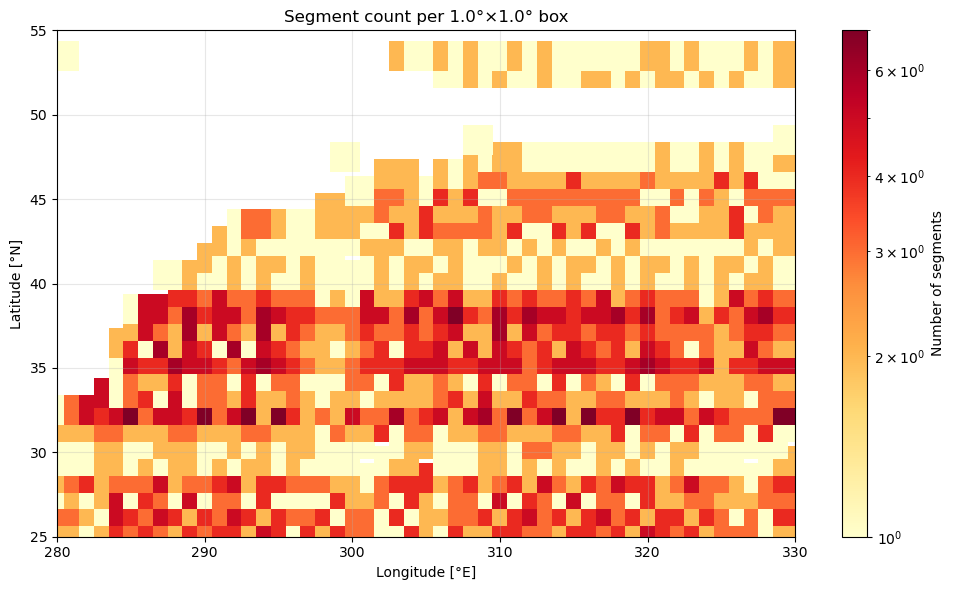

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes['lon_center'].values, ds_boxes['lat_center'].values,
    c=ds_boxes['n_segments'].values, s=(BOX_DEG * 60) ** 1.5,
    marker='s', cmap='YlOrRd',
    norm=mcolors.LogNorm(vmin=1, vmax=float(ds_boxes['n_segments'].max())),
    edgecolors='none',
)
plt.colorbar(sc, ax=ax, label='Number of segments')
ax.set_xlim(LON_MIN, LON_MAX); ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°N]')
ax.set_title(f'Segment count per {BOX_DEG}°×{BOX_DEG}° box')
ax.grid(True, alpha=0.3); fig.tight_layout()

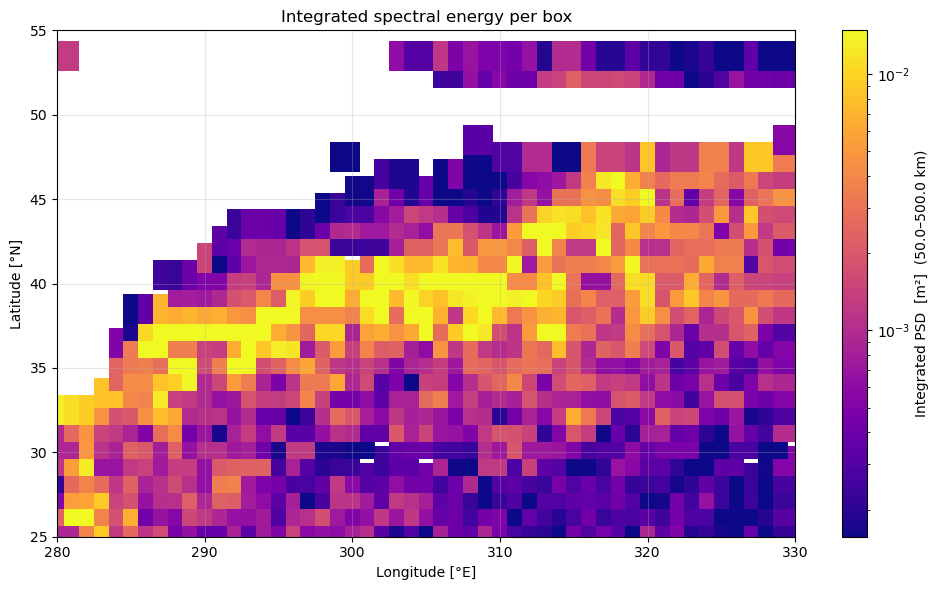

In [39]:
K_MIN, K_MAX = 1/500, 1/50
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes['lon_center'].values, ds_boxes['lat_center'].values,
    c=energy, s=(BOX_DEG * 60) ** 1.5, marker='s', cmap='plasma',
    norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                          vmax=np.nanpercentile(energy, 95)),
    edgecolors='none',
)
plt.colorbar(sc, ax=ax,
             label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)')
ax.set_xlim(LON_MIN, LON_MAX); ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°N]')
ax.set_title('Integrated spectral energy per box')
ax.grid(True, alpha=0.3); fig.tight_layout()

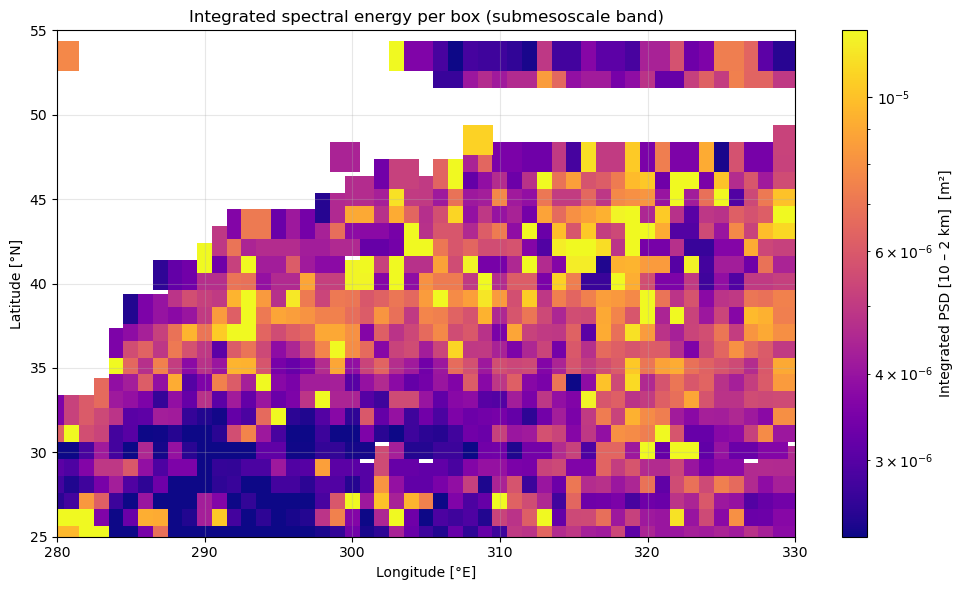

In [40]:
# Integrate the mean PSD over the submesoscale wavenumber band
K_MIN, K_MAX = 1/10, 1/2  # cycles/km

k = ds_boxes["wavenumber"].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk = np.gradient(k)

psd_vals = ds_boxes["mean_psd"].values          # (n_boxes, nk)
energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)  # (n_boxes,)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=energy,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="plasma",
    norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                          vmax=np.nanpercentile(energy, 95)),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label=f"Integrated PSD [{1/K_MIN:.0f} – {1/K_MAX:.0f} km]  [m²]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title("Integrated spectral energy per box (submesoscale band)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

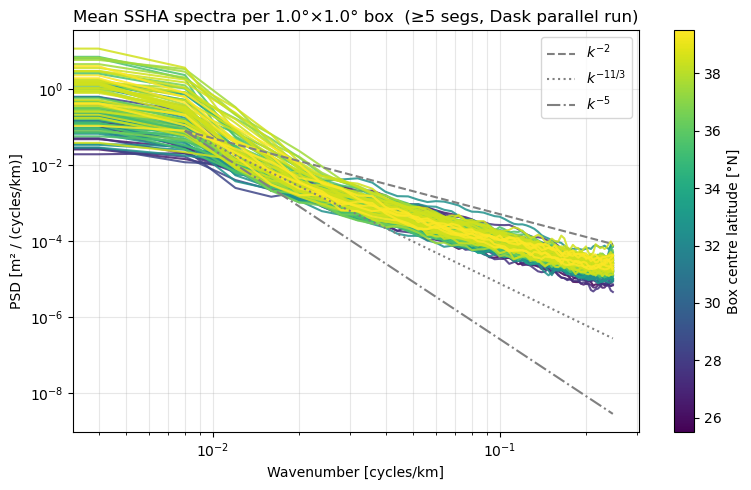

In [41]:
MIN_SEGMENTS_PER_BOX = 5
good = ds_boxes.where(ds_boxes['n_segments'] >= MIN_SEGMENTS_PER_BOX, drop=True)
lat_vals = good['lat_center'].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(good.sizes['box']):
    box = good.isel(box=i)
    ax.loglog(box['wavenumber'], box['mean_psd'],
              color=cmap(norm(float(box['lat_center']))), lw=1.5, alpha=0.85)

k_ref = good['wavenumber'].values[2:]
psd0  = float(good['mean_psd'].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, '--'), (-11/3, ':'), (-5, '-.')):  
    lbl = {-2: '$k^{-2}$', -11/3: '$k^{-11/3}$', -5: '$k^{-5}$'}[exp]
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color='gray', label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label='Box centre latitude [°N]')
ax.set_xlabel('Wavenumber [cycles/km]')
ax.set_ylabel('PSD [m² / (cycles/km)]')
ax.set_title(f'Mean SSHA spectra per {BOX_DEG}°×{BOX_DEG}° box  '
             f'(≥{MIN_SEGMENTS_PER_BOX} segs, Dask parallel run)')
ax.legend(); ax.grid(True, which='both', alpha=0.3); fig.tight_layout()

110 boxes with ≥ 5 segments


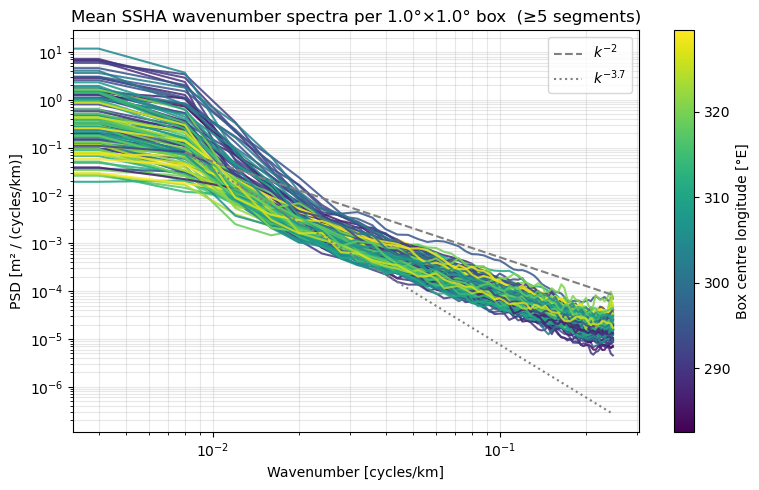

In [42]:
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
#good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lon_vals = good_boxes["lon_center"].values
norm = plt.Normalize(vmin=lon_vals.min(), vmax=lon_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(good_boxes.sizes["box"]):
    box = good_boxes.isel(box=i)
    ax.loglog(box["wavenumber"], box["mean_psd"],
              color=cmap(norm(float(box["lon_center"]))),
              lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.67", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## Spectra: mean PSD per box averaged per latitude and longitude

Boxes with fewer than `MIN_SEGMENTS_PER_BOX` segments are excluded to avoid noisy estimates.

110 boxes with ≥ 5 segments


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lat_center because variable lat_center is not a coordinate. To create an index for lat_center, please first call `.set_coords('lat_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


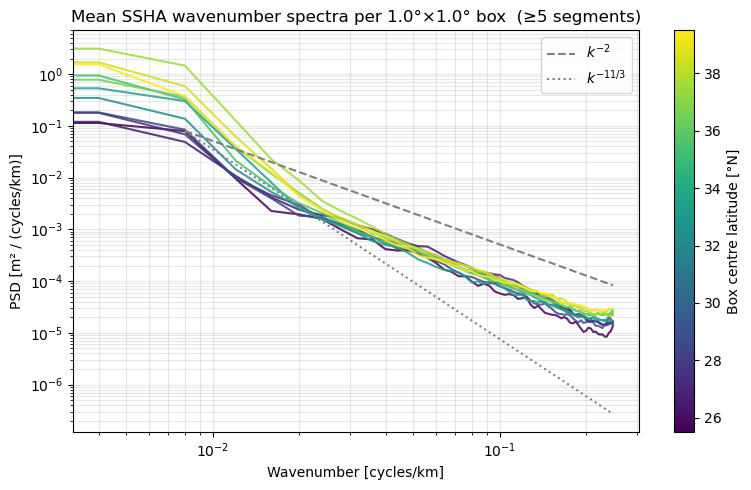

In [43]:
# Zonal average
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
#good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = good_boxes["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = good_boxes.groupby('lat_center').mean()
#for i in range(good_boxes.sizes["box"]):
    #box = good_boxes.isel(box=i)
for i in range(box.sizes["lat_center"]):
    lat_box = box.isel(lat_center = i)
    ax.loglog(lat_box["wavenumber"], lat_box["mean_psd"],color=cmap(norm(float(lat_box["lat_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

110 boxes with ≥ 5 segments


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lon_center because variable lon_center is not a coordinate. To create an index for lon_center, please first call `.set_coords('lon_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


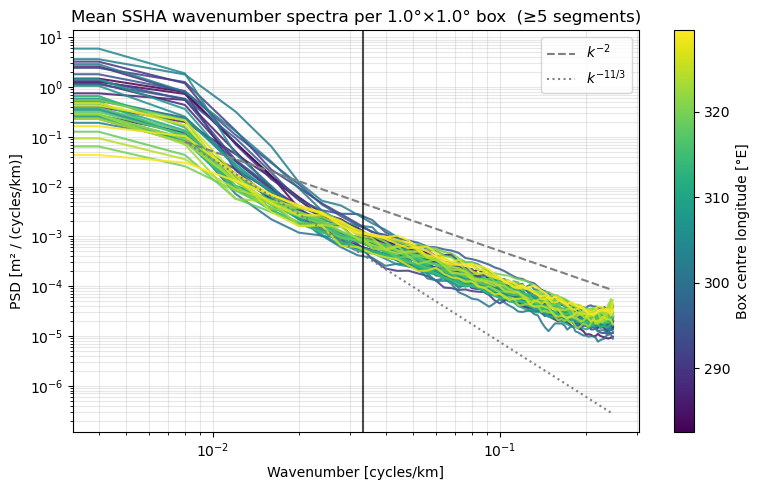

In [44]:
#Meridional average
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lon_vals = good_boxes["lon_center"].values
norm = plt.Normalize(vmin=lon_vals.min(), vmax=lon_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = good_boxes.groupby('lon_center').mean()
#for i in range(good_boxes.sizes["box"]):
    #box = good_boxes.isel(box=i)
for i in range(box.sizes["lon_center"]):
    lon_box = box.isel(lon_center = i)
    ax.loglog(lon_box["wavenumber"], lon_box["mean_psd"],color=cmap(norm(float(lon_box["lon_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend();
ax.axvline(1/30,ls='-',c='k',alpha=0.7)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_15844/2523140765.py:8: RuntimeWarning: divide by zero encountered in log10
  k_vals = np.log10(ds_boxes["wavenumber"].values)          # (n_boxes, nk)


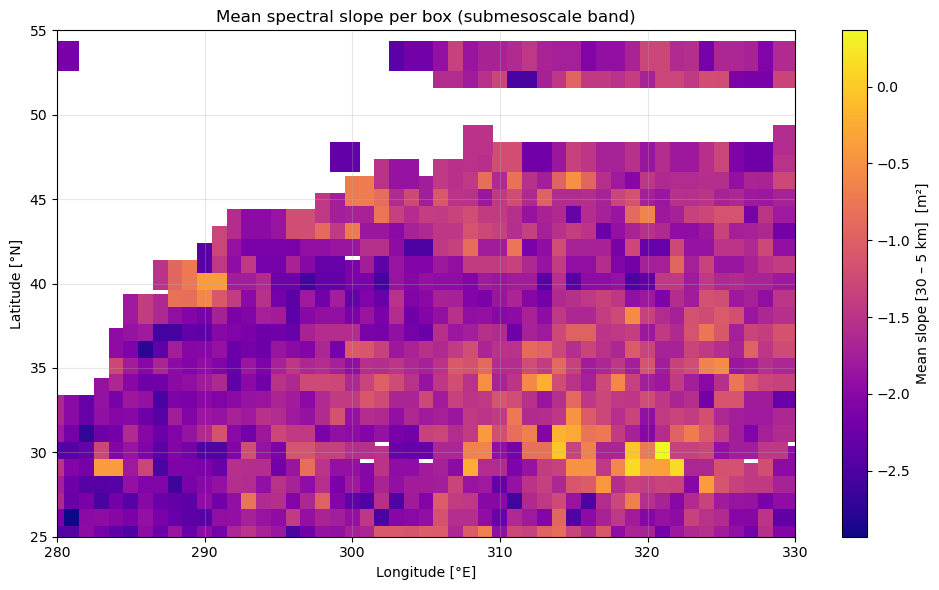

In [45]:
K_MIN, K_MAX = 1/30, 1/5  # cycles/km

k = ds_boxes["wavenumber"].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk = np.gradient(k)

psd_vals = np.log10(ds_boxes["mean_psd"].values)          # (n_boxes, nk)
k_vals = np.log10(ds_boxes["wavenumber"].values)          # (n_boxes, nk)
slope_mean = np.nanmean(np.diff(psd_vals,axis=1)/np.diff(k_vals),axis=1)
#energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)  # (n_boxes,)\

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=slope_mean,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="plasma",
    #norm=mcolors.LogNorm(vmin=np.nanpercentile(slope_mean, 5),
    #                      vmax=np.nanpercentile(slope_mean, 95)),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label=f"Mean slope [{1/K_MIN:.0f} – {1/K_MAX:.0f} km]  [m²]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title("Mean spectral slope per box (submesoscale band)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 9. Save and shut down

In [46]:
# ds_segments.to_netcdf('swot_expert_segments_dask.nc')
# ds_boxes.to_netcdf('swot_expert_box_spectra_dask.nc')

In [47]:
# Shut down the cluster when done.
client.close()
cluster.close()